In [ ]:
pip install numpy pandas scikit-learn torch matplotlib seaborn imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from imblearn.over_sampling import SMOTE

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


## 1. Data Loading

In [ ]:
# ------------------------------------------------------------------
# Step 1: Load raw training and test CSV files
# The dataset contains 561 IMU sensor features per time window,
# a subject ID, and an activity label.
# ------------------------------------------------------------------
train_data = pd.read_csv('/kaggle/input/dataset/train.csv')
test_data  = pd.read_csv('/kaggle/input/dataset/test.csv')

print('Training set shape:', train_data.shape)
print('Test set shape:     ', test_data.shape)

# Step 2: Inspect basic dataset properties
print('\nTraining dataset info:')
train_data.info()

# Step 3: Check for missing values and duplicates
missing = train_data.isna().sum()
print('\nMissing values:', missing[missing > 0].to_dict() or 'None')
print('Duplicate rows:', train_data.duplicated().sum())
print('Duplicate columns:', train_data.columns.duplicated().sum())

# Step 4: Summarise the target variable
print('\nUnique activities:', train_data['Activity'].unique())
print('Unique subjects:  ', sorted(train_data['subject'].unique()))
print('\nActivity distribution (training):')
activity_counts = train_data['Activity'].value_counts()
print(activity_counts)

subject_counts = train_data['subject'].value_counts()


Size of the training CSV:
(7352, 563)

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB
None

Columns in the training CSV:



Unique values in 'Activity' column:
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']

Unique values in 'subject' column:
[ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]

Number of unique subjects:
21

Distribution of activities:
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Distribution of subjects:
subject
25    409
21    408
26    392
30    383
28    382
27    376
23    372
17    368
16    366
19    360
1     347
29    344
3     341
15    328
6     325
14    323
22    321
11    316
7     308
5     302
8     281
Name: count, dtype: int64

Missing values in the training dataset:
Series([], dtype: int64)

Number of duplicated rows:
0

Number of duplicated columns:
0


## 2. Exploratory Data Analysis

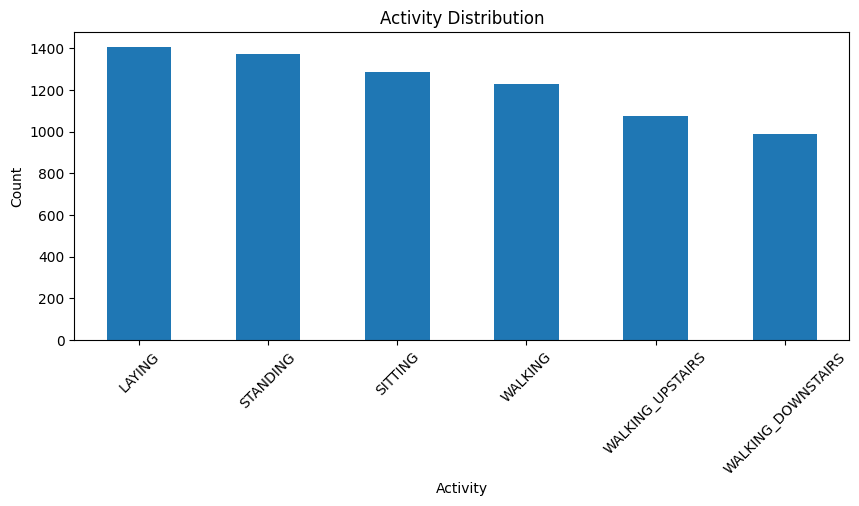

In [ ]:
# Distribution of activity labels in the training set
plt.figure(figsize=(10, 4))
activity_counts.plot(kind='bar')
plt.title('Activity Distribution (Training Set)')
plt.xlabel('Activity')
plt.ylabel('Sample Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


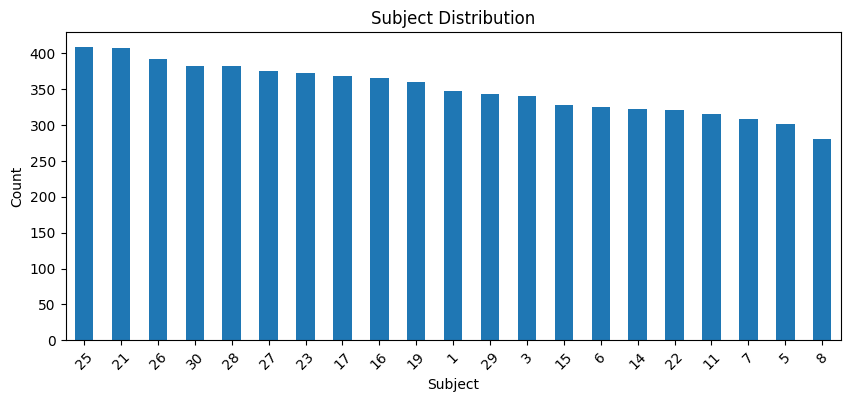

In [ ]:
# Number of samples contributed by each subject
plt.figure(figsize=(10, 4))
subject_counts.plot(kind='bar')
plt.title('Sample Count per Subject (Training Set)')
plt.xlabel('Subject ID')
plt.ylabel('Sample Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


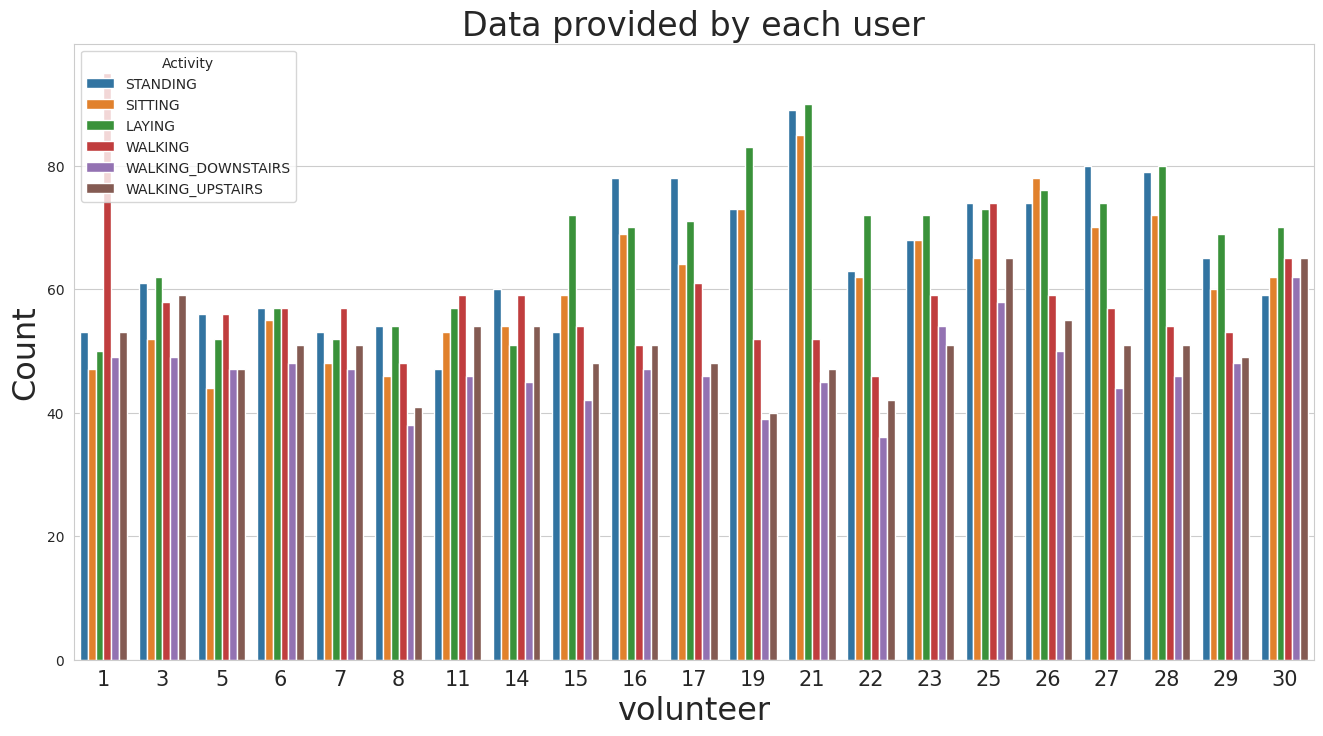

In [ ]:
# Activity breakdown per subject — shows how activities are distributed
# across individual participants
plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')
sns.color_palette('tab10')
sns.countplot(x='subject', hue='Activity', data=train_data)
plt.title('Activity Count per Subject', fontsize=24)
plt.xlabel('Subject ID', size=23)
plt.ylabel('Count', size=23)
plt.xticks(size=15)
plt.tight_layout()
plt.show()


Correlation Matrix:


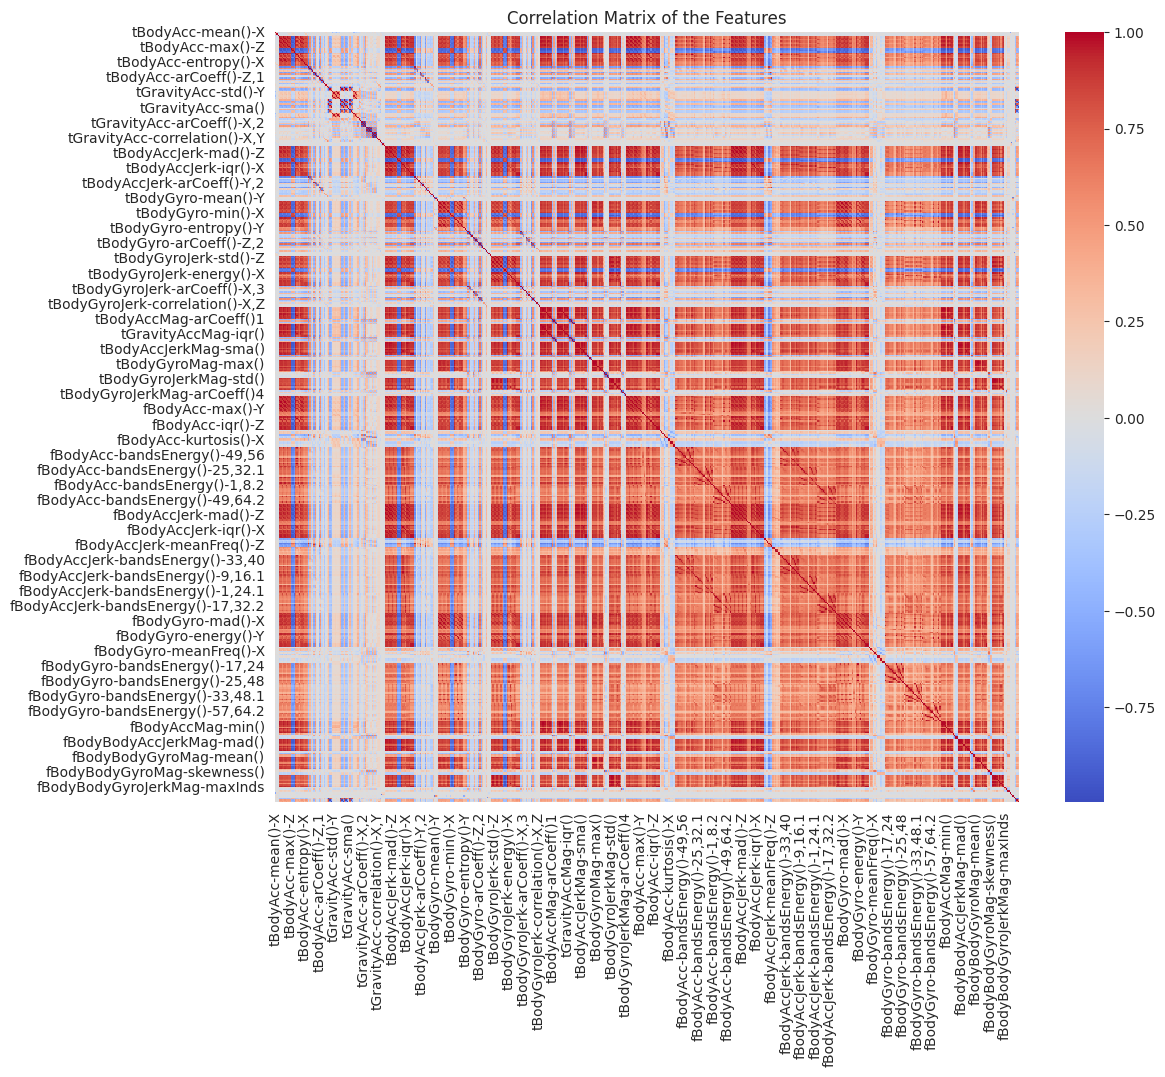

In [ ]:
# Correlation heatmap of the 561 sensor features.
# High inter-feature correlation motivates PCA dimensionality reduction.
correlation_matrix = train_data.drop(['Activity', 'subject'], axis=1).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 3. Preprocessing — Label Encoding & Class Balancing

In [ ]:
# ------------------------------------------------------------------
# Step 1: Separate features from the target label
# ------------------------------------------------------------------
X_raw = train_data.drop(columns=['Activity', 'subject'])
y_raw = train_data['Activity']

# Step 2: Encode string activity labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print('Encoded classes:', list(le.classes_))

# Step 3: Standardise features (zero mean, unit variance)
# The fitted scaler is reused later to transform the test set.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Step 4: Apply SMOTE to oversample minority classes
# This ensures each of the 6 activities has an equal number of samples.
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y_encoded)

# Reconstruct a balanced DataFrame for downstream use
train_data_balanced = pd.DataFrame(X_balanced, columns=X_raw.columns)
train_data_balanced['Activity'] = le.inverse_transform(y_balanced)

print('\nActivity distribution after SMOTE balancing:')
print(train_data_balanced['Activity'].value_counts())



Distribution of activities after balancing:
Activity
STANDING              1407
SITTING               1407
LAYING                1407
WALKING               1407
WALKING_DOWNSTAIRS    1407
WALKING_UPSTAIRS      1407
Name: count, dtype: int64


## 4. Dimensionality Reduction (PCA)

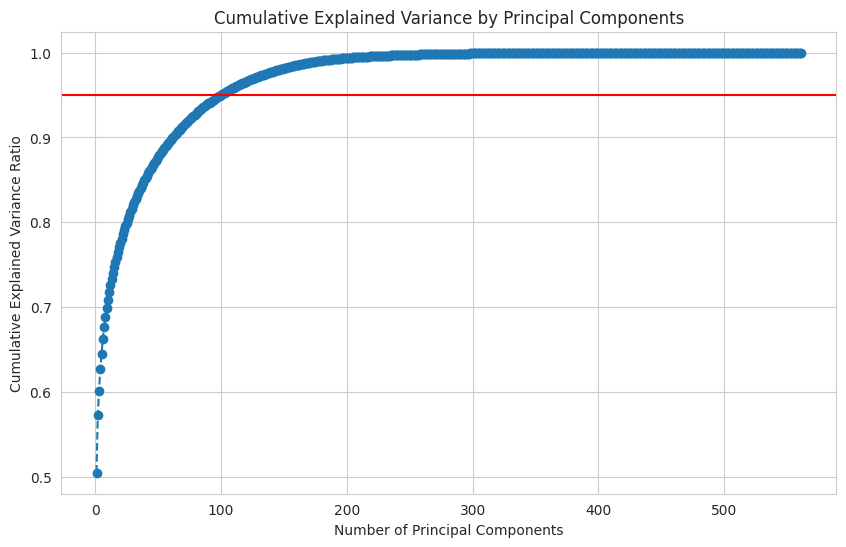

Number of components that explain 95% of the variance: 100


In [ ]:
# ------------------------------------------------------------------
# Step 1: Re-standardise the balanced training features
# (SMOTE may shift the feature distribution slightly)
# ------------------------------------------------------------------
features = train_data_balanced.drop(['Activity'], axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 2: Fit a full PCA to inspect cumulative explained variance
pca_full = PCA(n_components=None)
pca_full.fit_transform(scaled_features)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Step 3: Plot cumulative explained variance to choose n_components
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', linestyle='--', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% threshold')
plt.title('Cumulative Explained Variance by Number of PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Components needed to explain 95% of variance: {n_components_95}')


In [ ]:
# ------------------------------------------------------------------
# Step 1: Fit PCA with the chosen number of components (100)
# and transform the balanced training data.
# ------------------------------------------------------------------
N_COMPONENTS = 100
pca_95 = PCA(n_components=N_COMPONENTS)
pca_result = pca_95.fit_transform(scaled_features)
print(f'Transformed training set shape: {pca_result.shape}')

# Step 2: Wrap the PCA output in a DataFrame for easier manipulation
pca_columns = [f'PC{i+1}' for i in range(N_COMPONENTS)]
pca_df = pd.DataFrame(data=pca_result, columns=pca_columns)

# Step 3: Attach integer-encoded activity labels
# Re-encode labels from the balanced set to keep indices consistent.
le = LabelEncoder()
pca_df['Activity'] = le.fit_transform(train_data_balanced['Activity'].values)

print('Encoded class mapping:', dict(enumerate(le.classes_)))
print(pca_df.head())


Shape of the transformed dataset: (8442, 100)


         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -17.544645  2.531734  3.018908  1.565791  6.491046 -4.393084 -2.082183   
1 -16.710224  1.661845  0.138098 -2.597662  4.427009 -2.292110  0.447517   
2 -16.546301  2.739936 -0.698311 -3.815353  4.417126 -1.612254  0.284753   
3 -16.757134  4.212520 -1.118781 -2.768548  3.386169 -1.144816 -0.047363   
4 -16.939993  4.880143 -1.396099 -3.171488  3.296217 -1.436885  1.321403   

        PC8       PC9      PC10  ...      PC92      PC93      PC94      PC95  \
0  4.846326  0.736018 -4.348474  ... -2.207800  0.915222  1.172266 -0.479055   
1  1.814484  0.505658 -0.459881  ... -0.049632 -0.235365 -0.202382  0.181735   
2  1.257649  0.708176 -0.785552  ... -0.270136  0.696465  0.561922  0.579379   
3  1.701461  1.590329 -1.263530  ... -0.259649 -1.309914 -1.028028  0.874690   
4  0.671925  0.041510  0.721077  ...  0.607601  0.357260 -0.095899 -0.174622   

       PC96      PC97      PC98      PC99     PC100  Activity 

## 5. SVM Classification

In [ ]:
# ------------------------------------------------------------------
# Step 1: Extract feature matrix X and label vector y from pca_df
# ------------------------------------------------------------------
X = pca_df.drop(['Activity'], axis=1).values
y = pca_df['Activity'].values

# Step 2: Stratified 80/20 train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]}')

# Step 3: Train an RBF-kernel SVM
# C=1 and gamma='scale' are sklearn defaults; good starting point.
svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
print('SVM training complete.')


SVC(C=1, random_state=42)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       281
           SITTING       0.94      0.91      0.92       281
          STANDING       0.91      0.94      0.93       282
           WALKING       1.00      1.00      1.00       282
WALKING_DOWNSTAIRS       1.00      1.00      1.00       282
  WALKING_UPSTAIRS       1.00      1.00      1.00       281

          accuracy                           0.97      1689
         macro avg       0.97      0.97      0.97      1689
      weighted avg       0.97      0.97      0.97      1689



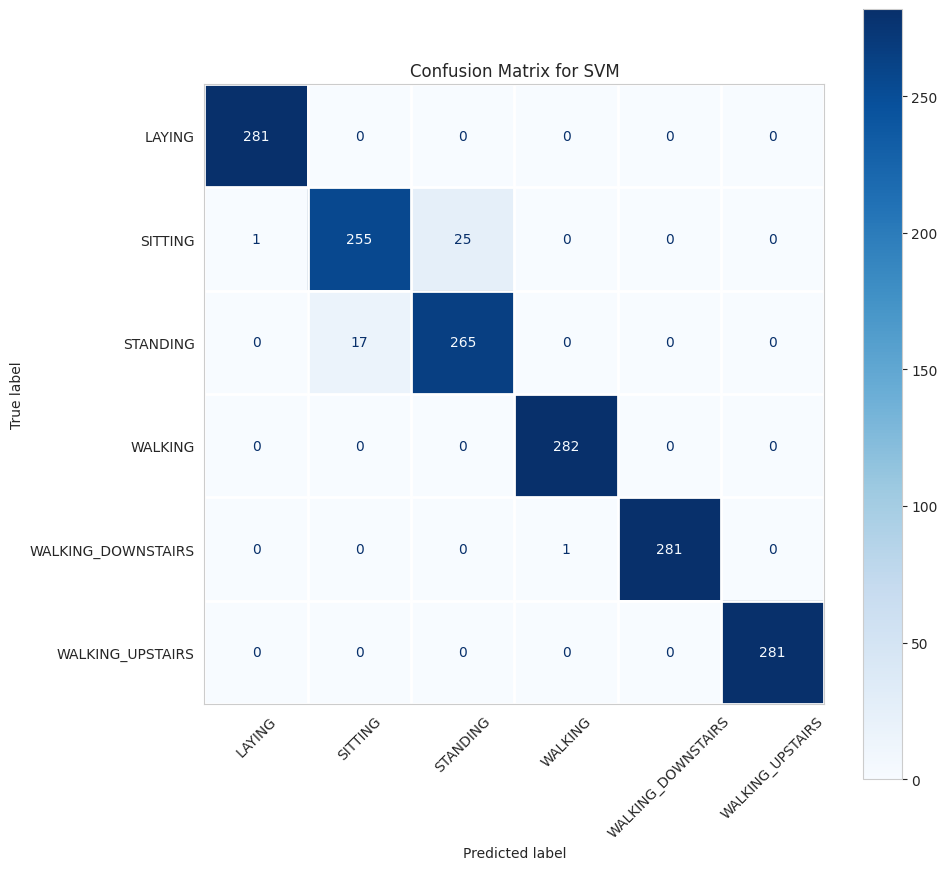

Accuracy: 0.9739
F1 Score: 0.9739


In [ ]:
# ------------------------------------------------------------------
# Step 1: Generate predictions on the validation split
# ------------------------------------------------------------------
y_pred_svm = svm_model.predict(X_val)

# Step 2: Per-class classification report
print(classification_report(y_val, y_pred_svm, target_names=le.classes_))

# Step 3: Confusion matrix
cm = confusion_matrix(y_val, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title('SVM — Confusion Matrix (Validation Set)')
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', size=0)
plt.tight_layout()
plt.show()

# Step 4: Summary metrics
svm_accuracy = accuracy_score(y_val, y_pred_svm)
svm_f1       = f1_score(y_val, y_pred_svm, average='weighted')
print(f'SVM Validation Accuracy : {svm_accuracy:.4f}')
print(f'SVM Validation F1 Score : {svm_f1:.4f}')


## 6. Fully-Connected Neural Network

In [ ]:
class SimpleNN(nn.Module):
    """
    Three-layer fully-connected classifier.
    Architecture: Linear(input→128) → ReLU → Dropout(0.5)
                  → Linear(128→64) → ReLU → Dropout(0.5)
                  → Linear(64→num_classes)
    """
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.fc1     = nn.Linear(input_size, 128)
        self.fc2     = nn.Linear(128, 64)
        self.fc3     = nn.Linear(64, num_classes)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        return self.fc3(x)


Fold 1
Fold 1 Train Accuracy: 0.9738
Fold 1 Validation Accuracy: 0.9609
Fold 1 Validation Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.90      0.88      0.89       281
          STANDING       0.89      0.90      0.90       282
           WALKING       1.00      0.99      0.99       281
WALKING_DOWNSTAIRS       1.00      0.99      1.00       281
  WALKING_UPSTAIRS       0.98      1.00      0.99       282

          accuracy                           0.96      1689
         macro avg       0.96      0.96      0.96      1689
      weighted avg       0.96      0.96      0.96      1689



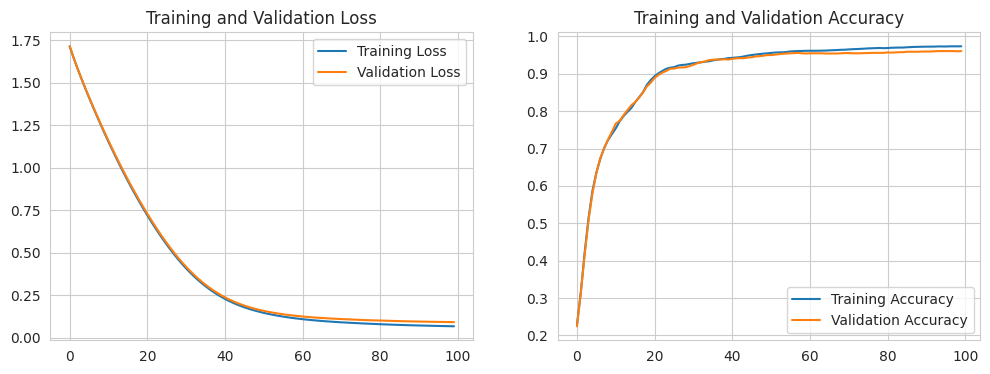

Fold 2
Fold 2 Train Accuracy: 0.9704
Fold 2 Validation Accuracy: 0.9745
Fold 2 Validation Report:
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      0.99       281
           SITTING       0.94      0.91      0.93       281
          STANDING       0.93      0.94      0.94       282
           WALKING       1.00      1.00      1.00       282
WALKING_DOWNSTAIRS       1.00      1.00      1.00       281
  WALKING_UPSTAIRS       1.00      0.99      0.99       282

          accuracy                           0.97      1689
         macro avg       0.97      0.97      0.97      1689
      weighted avg       0.97      0.97      0.97      1689



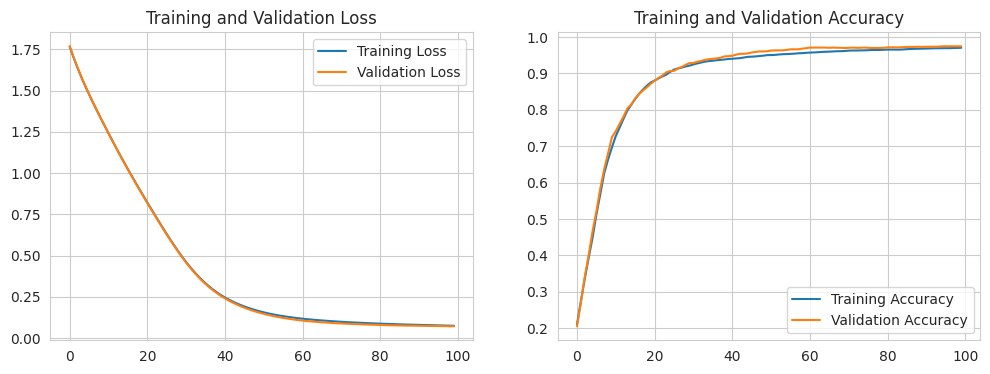

Fold 3
Fold 3 Train Accuracy: 0.9729
Fold 3 Validation Accuracy: 0.9615
Fold 3 Validation Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       281
           SITTING       0.89      0.90      0.89       282
          STANDING       0.90      0.88      0.89       281
           WALKING       0.99      0.99      0.99       282
WALKING_DOWNSTAIRS       1.00      1.00      1.00       281
  WALKING_UPSTAIRS       0.99      0.99      0.99       281

          accuracy                           0.96      1688
         macro avg       0.96      0.96      0.96      1688
      weighted avg       0.96      0.96      0.96      1688



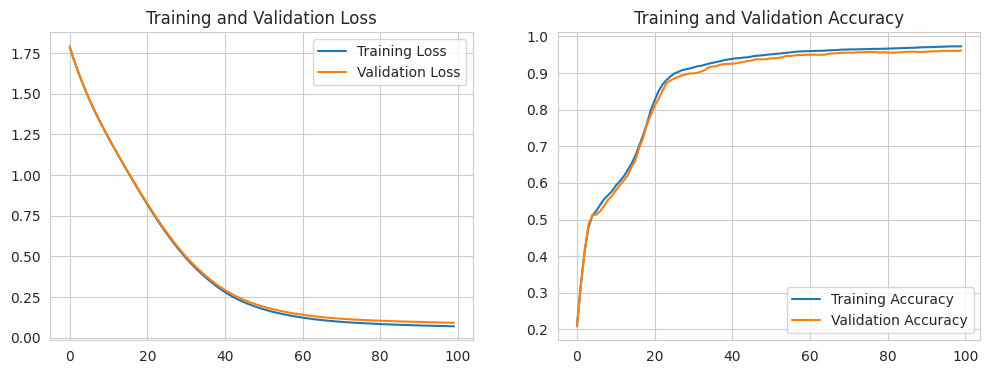

Fold 4
Fold 4 Train Accuracy: 0.9714
Fold 4 Validation Accuracy: 0.9609
Fold 4 Validation Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       281
           SITTING       0.90      0.90      0.90       282
          STANDING       0.90      0.90      0.90       281
           WALKING       1.00      0.99      0.99       281
WALKING_DOWNSTAIRS       0.97      1.00      0.98       282
  WALKING_UPSTAIRS       1.00      0.97      0.99       281

          accuracy                           0.96      1688
         macro avg       0.96      0.96      0.96      1688
      weighted avg       0.96      0.96      0.96      1688



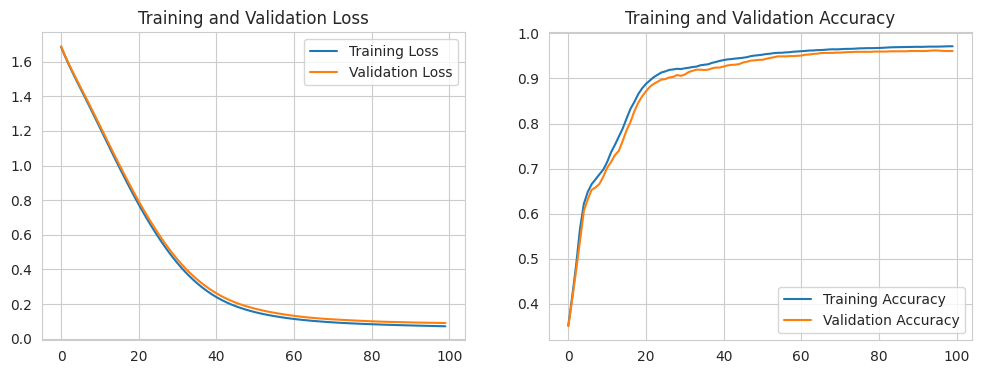

Fold 5
Fold 5 Train Accuracy: 0.9708
Fold 5 Validation Accuracy: 0.9662
Fold 5 Validation Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.90      0.90      0.90       281
          STANDING       0.91      0.90      0.91       281
           WALKING       1.00      1.00      1.00       281
WALKING_DOWNSTAIRS       0.99      1.00      0.99       282
  WALKING_UPSTAIRS       1.00      0.99      0.99       281

          accuracy                           0.97      1688
         macro avg       0.97      0.97      0.97      1688
      weighted avg       0.97      0.97      0.97      1688



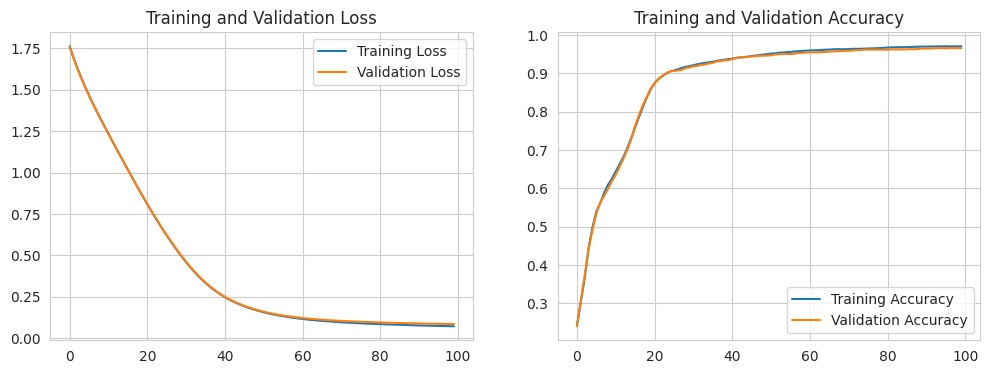

Average Train Accuracy: 0.9719
Average Validation Accuracy: 0.9648
Average Train F1 Score: 0.9719
Average Validation F1 Score: 0.9648
Best Fold: 2 with Validation Accuracy: 0.9745


In [ ]:
# ------------------------------------------------------------------
# 5-fold stratified cross-validation for SimpleNN
# Each fold trains a fresh model, applies early stopping, and saves
# the best checkpoint if it beats the previous best validation accuracy.
# ------------------------------------------------------------------
NUM_EPOCHS  = 100
PATIENCE    = 5
K_FOLDS     = 5

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

all_train_accuracies = []
all_val_accuracies   = []
all_train_f1_scores  = []
all_val_f1_scores    = []

best_fold_nn         = 0
best_val_accuracy_nn = 0.0

X_nn = pca_df.drop(['Activity'], axis=1).values
y_nn = pca_df['Activity'].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X_nn, y_nn), start=1):
    print(f'--- Fold {fold} ---')

    # Split and convert to tensors; move to the selected device
    X_train_f = torch.tensor(X_nn[train_idx], dtype=torch.float32).to(device)
    X_val_f   = torch.tensor(X_nn[val_idx],   dtype=torch.float32).to(device)
    y_train_f = torch.tensor(y_nn[train_idx].astype(int), dtype=torch.long).to(device)
    y_val_f   = torch.tensor(y_nn[val_idx].astype(int),   dtype=torch.long).to(device)

    # Initialise a fresh model for each fold
    input_size  = X_train_f.shape[1]
    num_classes = len(le.classes_)
    model       = SimpleNN(input_size, num_classes).to(device)
    criterion   = nn.CrossEntropyLoss()
    optimizer   = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss    = float('inf')
    best_model_wts   = None
    patience_counter = 0

    train_losses, val_losses         = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(NUM_EPOCHS):
        # Forward + backward pass on the training split
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_f), y_train_f)
        loss.backward()
        optimizer.step()

        # Evaluate on training split (no gradient)
        model.eval()
        with torch.no_grad():
            train_out  = model(X_train_f)
            train_loss = criterion(train_out, y_train_f).item()
            train_pred = torch.argmax(train_out, dim=1)
            train_acc  = (train_pred == y_train_f).float().mean().item()
            train_losses.append(train_loss)
            train_accuracies.append(train_acc)

            # Evaluate on validation split
            val_out  = model(X_val_f)
            val_loss = criterion(val_out, y_val_f).item()
            val_pred = torch.argmax(val_out, dim=1)
            val_acc  = (val_pred == y_val_f).float().mean().item()
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)

        # Early stopping: save checkpoint when validation loss improves
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_wts   = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch + 1}')
                break

    # Restore the best weights found during this fold
    model.load_state_dict(best_model_wts)

    # Compute fold-level metrics
    train_f1 = f1_score(y_train_f.cpu(), train_pred.cpu(), average='weighted')
    val_f1   = f1_score(y_val_f.cpu(),   val_pred.cpu(),   average='weighted')

    all_train_accuracies.append(train_acc)
    all_val_accuracies.append(val_acc)
    all_train_f1_scores.append(train_f1)
    all_val_f1_scores.append(val_f1)

    print(f'  Train Accuracy: {train_acc:.4f} | Val Accuracy: {val_acc:.4f}')
    print(classification_report(
        y_val_f.cpu(), val_pred.cpu(), target_names=le.classes_
    ))

    # Keep track of the globally best fold and save its weights
    if val_acc > best_val_accuracy_nn:
        best_val_accuracy_nn = val_acc
        best_fold_nn         = fold
        torch.save(model.state_dict(), 'best_model_NN.pth')

    # Plot training curves for this fold
    epochs_range = range(len(train_accuracies))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, train_losses,    label='Train Loss')
    axes[0].plot(epochs_range, val_losses,      label='Val Loss')
    axes[0].set_title(f'Fold {fold} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy')
    axes[1].plot(epochs_range, val_accuracies,   label='Val Accuracy')
    axes[1].set_title(f'Fold {fold} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# Cross-validation summary
print(f'Average Train Accuracy : {np.mean(all_train_accuracies):.4f}')
print(f'Average Val Accuracy   : {np.mean(all_val_accuracies):.4f}')
print(f'Average Train F1 Score : {np.mean(all_train_f1_scores):.4f}')
print(f'Average Val F1 Score   : {np.mean(all_val_f1_scores):.4f}')
print(f'Best Fold: {best_fold_nn}  |  Best Val Accuracy: {best_val_accuracy_nn:.4f}')


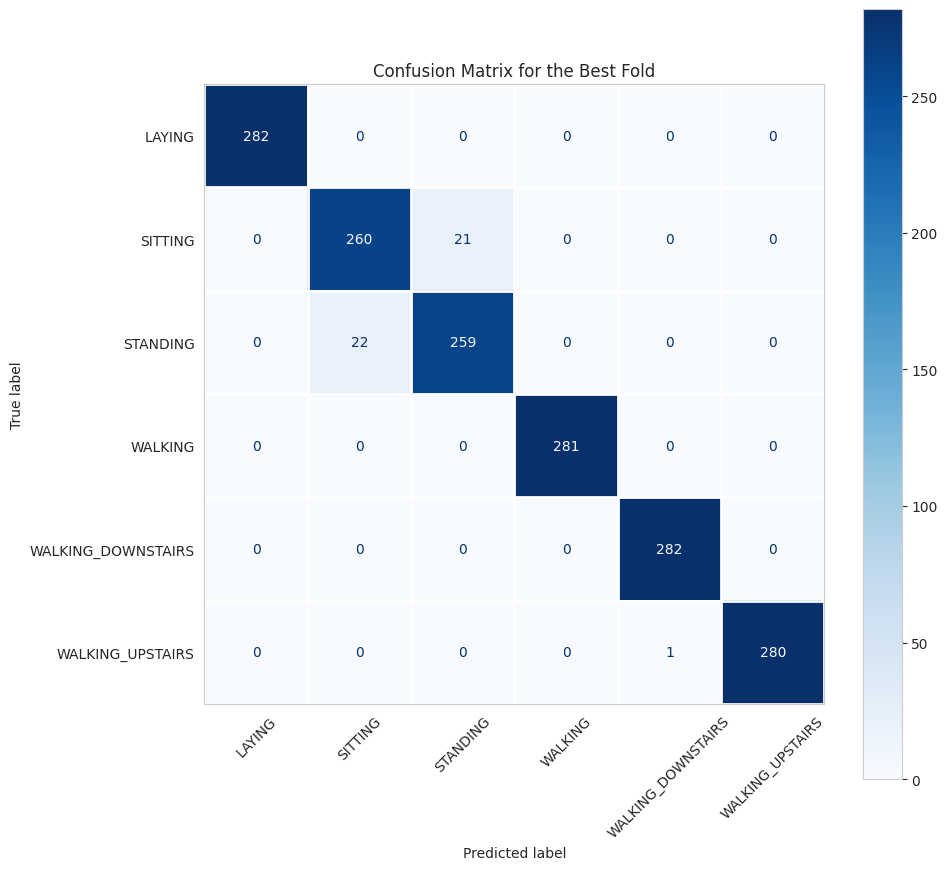

In [ ]:
# ------------------------------------------------------------------
# Load the best SimpleNN checkpoint and plot its confusion matrix
# ------------------------------------------------------------------
best_nn = SimpleNN(input_size, num_classes).to(device)
best_nn.load_state_dict(torch.load('best_model_NN.pth', map_location=device))
best_nn.eval()

# Run inference on the last fold's validation split
# (X_val_f and y_val_f still reference the final fold in the loop above)
with torch.no_grad():
    val_out  = best_nn(X_val_f)
    val_pred = torch.argmax(val_out, dim=1)

y_val_true_nn = y_val_f.cpu().numpy()
y_val_pred_nn = val_pred.cpu().numpy()

cm = confusion_matrix(y_val_true_nn, y_val_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title(f'SimpleNN — Confusion Matrix (Best Fold {best_fold_nn})')
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', size=0)
plt.tight_layout()
plt.show()


## 7. 1-D Convolutional Neural Network

In [ ]:
# ------------------------------------------------------------------
# The CNN expects input shape (batch, channels, length).
# We treat each PCA-reduced sample as a 1-channel 1-D signal.
# ------------------------------------------------------------------
X_cnn = pca_df.drop(['Activity'], axis=1).values
y_cnn = pca_df['Activity'].values

# unsqueeze(1) adds the channel dimension: (N, 100) → (N, 1, 100)
X_tensor = torch.tensor(X_cnn, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y_cnn, dtype=torch.long)

print(f'X_tensor shape: {X_tensor.shape}')  # Expected: (N, 1, 100)
print(f'y_tensor shape: {y_tensor.shape}')


In [ ]:
class SimpleCNN(nn.Module):
    """
    Lightweight 1-D CNN for sequence classification.
    Architecture:
      Conv1d(1→32, k=3) → ReLU → MaxPool(2)
      Conv1d(32→64, k=3) → ReLU → MaxPool(2)
      Flatten → Linear(1600→128) → ReLU → Dropout(0.5)
      Linear(128→num_classes)
    The fc1 input size assumes input_size=100 (100 PCA components):
      100 → MaxPool → 50 → MaxPool → 25 ; 25 * 64 channels = 1600
    """
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.conv1   = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2   = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu    = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        # After two MaxPool(2) operations the length is input_size // 4
        self.fc1 = nn.Linear(input_size * 64 // 4, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.conv1(x)))  # (B, 32, L/2)
        x = self.maxpool(self.relu(self.conv2(x)))  # (B, 64, L/4)
        x = x.view(x.size(0), -1)                   # Flatten
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


Fold 1
Fold 1 Train Accuracy: 0.9856
Fold 1 Validation Accuracy: 0.9663
Fold 1 Train F1 Score: 0.9856
Fold 1 Validation F1 Score: 0.9662


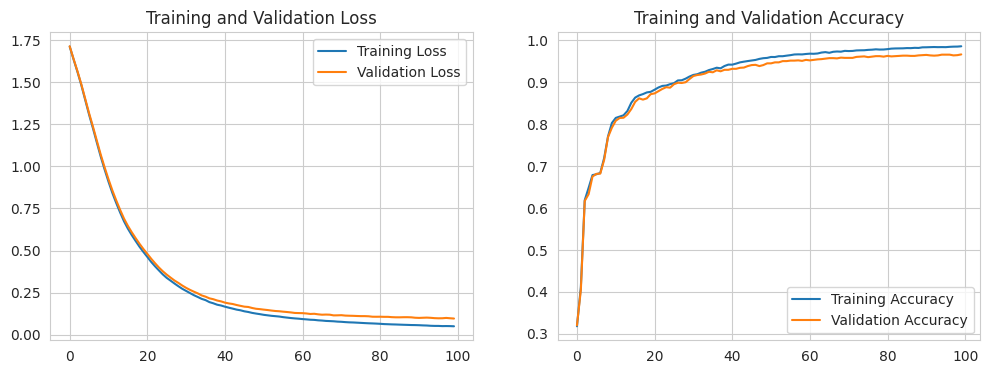

Fold 2
Fold 2 Train Accuracy: 0.9810
Fold 2 Validation Accuracy: 0.9728
Fold 2 Train F1 Score: 0.9810
Fold 2 Validation F1 Score: 0.9727


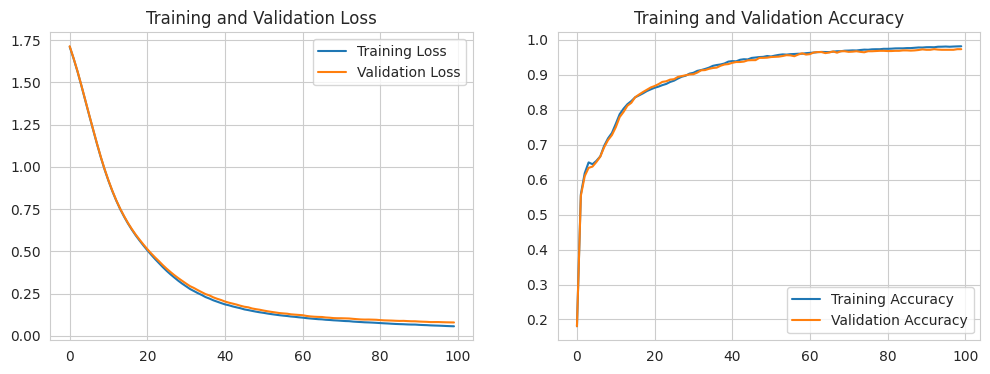

Fold 3
Fold 3 Train Accuracy: 0.9819
Fold 3 Validation Accuracy: 0.9579
Fold 3 Train F1 Score: 0.9819
Fold 3 Validation F1 Score: 0.9579


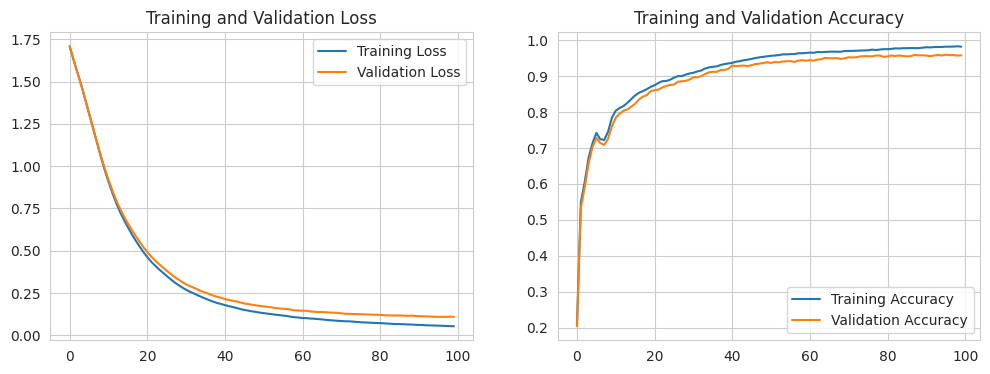

Fold 4
Fold 4 Train Accuracy: 0.9815
Fold 4 Validation Accuracy: 0.9609
Fold 4 Train F1 Score: 0.9815
Fold 4 Validation F1 Score: 0.9609


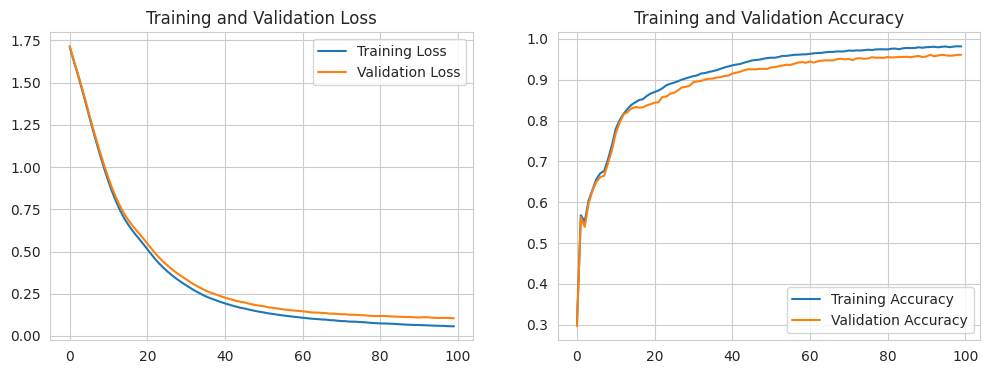

Fold 5
Fold 5 Train Accuracy: 0.9822
Fold 5 Validation Accuracy: 0.9716
Fold 5 Train F1 Score: 0.9822
Fold 5 Validation F1 Score: 0.9716


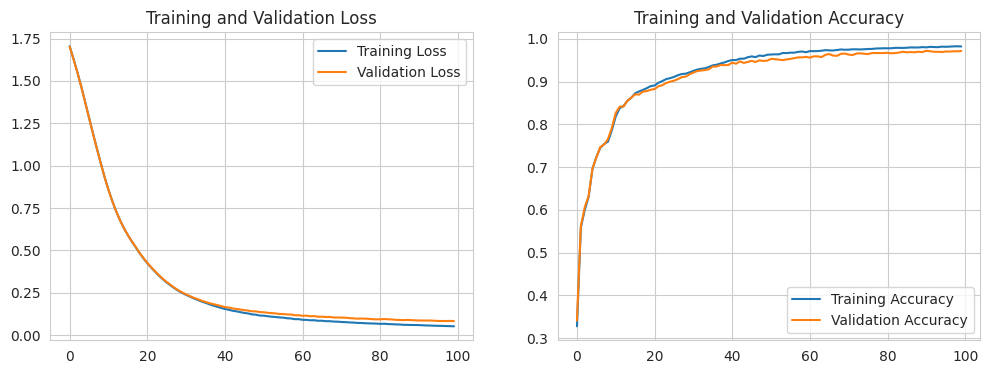

Average Train Accuracy: 0.9825
Average Validation Accuracy: 0.9659
Average Train F1 Score: 0.9825
Average Validation F1 Score: 0.9658
Best Fold: 2 with Validation Accuracy: 0.9728


In [ ]:
# ------------------------------------------------------------------
# 5-fold stratified cross-validation for SimpleCNN
# Identical strategy to the SimpleNN section above.
# ------------------------------------------------------------------
NUM_EPOCHS  = 100
PATIENCE    = 5
K_FOLDS     = 5

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

all_train_accuracies = []
all_val_accuracies   = []
all_train_f1_scores  = []
all_val_f1_scores    = []

best_fold_cnn         = 0
best_val_accuracy_cnn = 0.0

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cnn, y_cnn), start=1):
    print(f'--- Fold {fold} ---')

    # Slice pre-built tensors and move to the selected device
    X_train_f = X_tensor[train_idx].to(device)
    X_val_f   = X_tensor[val_idx].to(device)
    y_train_f = y_tensor[train_idx].to(device)
    y_val_f   = y_tensor[val_idx].to(device)

    # Initialise a fresh CNN for each fold
    input_size  = X_train_f.shape[2]   # number of PCA components (100)
    num_classes = len(le.classes_)
    model       = SimpleCNN(input_size, num_classes).to(device)
    criterion   = nn.CrossEntropyLoss()
    optimizer   = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss    = float('inf')
    best_model_wts   = None
    patience_counter = 0

    train_losses, val_losses         = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_f), y_train_f)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_out  = model(X_train_f)
            train_loss = criterion(train_out, y_train_f).item()
            train_pred = torch.argmax(train_out, dim=1)
            train_acc  = (train_pred == y_train_f).float().mean().item()
            train_losses.append(train_loss)
            train_accuracies.append(train_acc)

            val_out  = model(X_val_f)
            val_loss = criterion(val_out, y_val_f).item()
            val_pred = torch.argmax(val_out, dim=1)
            val_acc  = (val_pred == y_val_f).float().mean().item()
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_wts   = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch + 1}')
                break

    model.load_state_dict(best_model_wts)

    train_f1 = f1_score(y_train_f.cpu(), train_pred.cpu(), average='weighted')
    val_f1   = f1_score(y_val_f.cpu(),   val_pred.cpu(),   average='weighted')

    all_train_accuracies.append(train_acc)
    all_val_accuracies.append(val_acc)
    all_train_f1_scores.append(train_f1)
    all_val_f1_scores.append(val_f1)

    print(f'  Train Accuracy: {train_acc:.4f} | Val Accuracy: {val_acc:.4f}')
    print(f'  Train F1: {train_f1:.4f}        | Val F1: {val_f1:.4f}')

    if val_acc > best_val_accuracy_cnn:
        best_val_accuracy_cnn = val_acc
        best_fold_cnn         = fold
        torch.save(model.state_dict(), 'best_model_CNN.pth')

    epochs_range = range(len(train_accuracies))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, train_losses,    label='Train Loss')
    axes[0].plot(epochs_range, val_losses,      label='Val Loss')
    axes[0].set_title(f'Fold {fold} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy')
    axes[1].plot(epochs_range, val_accuracies,   label='Val Accuracy')
    axes[1].set_title(f'Fold {fold} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print(f'Average Train Accuracy : {np.mean(all_train_accuracies):.4f}')
print(f'Average Val Accuracy   : {np.mean(all_val_accuracies):.4f}')
print(f'Average Train F1 Score : {np.mean(all_train_f1_scores):.4f}')
print(f'Average Val F1 Score   : {np.mean(all_val_f1_scores):.4f}')
print(f'Best Fold: {best_fold_cnn}  |  Best Val Accuracy: {best_val_accuracy_cnn:.4f}')


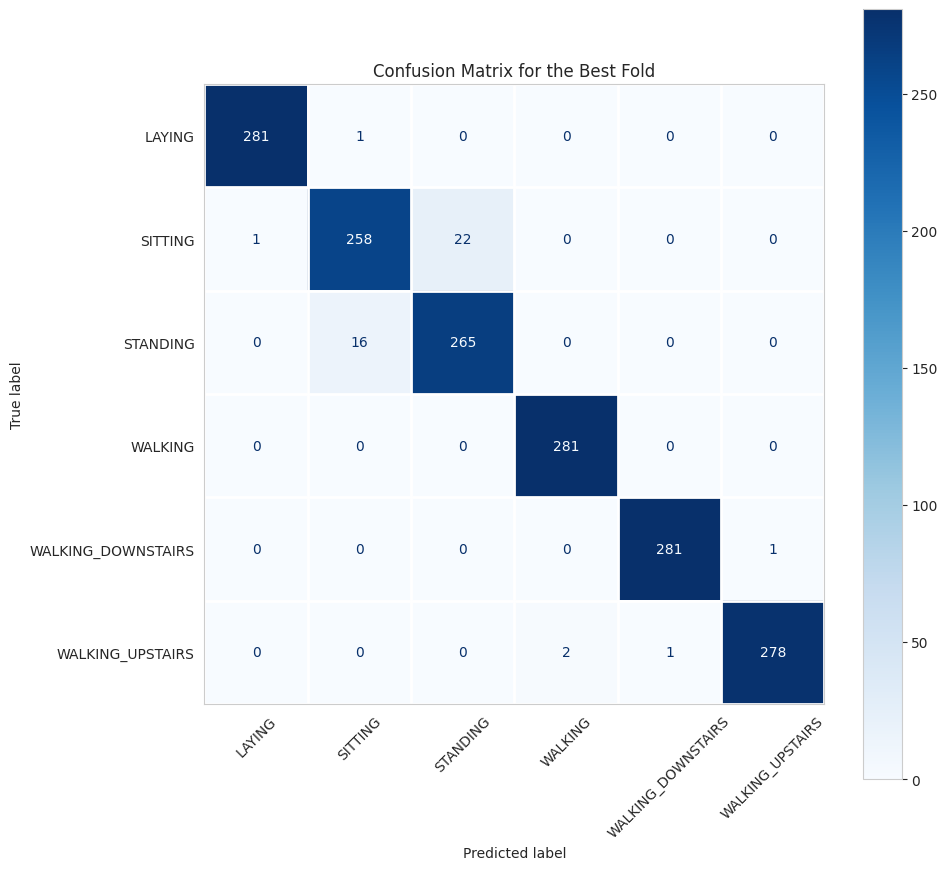

In [ ]:
# ------------------------------------------------------------------
# Load the best CNN checkpoint and plot its confusion matrix
# X_val_f and y_val_f retain the last fold's data from the loop above.
# ------------------------------------------------------------------
best_cnn = SimpleCNN(input_size, num_classes).to(device)
best_cnn.load_state_dict(torch.load('best_model_CNN.pth', map_location=device))
best_cnn.eval()

with torch.no_grad():
    val_out  = best_cnn(X_val_f)
    val_pred = torch.argmax(val_out, dim=1)

y_val_true_cnn = y_val_f.cpu().numpy()
y_val_pred_cnn = val_pred.cpu().numpy()

cm = confusion_matrix(y_val_true_cnn, y_val_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title(f'SimpleCNN — Confusion Matrix (Best Fold {best_fold_cnn})')
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', size=0)
plt.tight_layout()
plt.show()


## 8. Final Evaluation on the Held-Out Test Set

In [ ]:
# ------------------------------------------------------------------
# Preprocess the held-out test set using the same transformations
# that were fitted on the training data (scaler and pca_95).
# Applying fit_transform here would cause data leakage.
# ------------------------------------------------------------------

# Step 1: Extract raw features and true activity labels from test_data
X_test_raw      = test_data.drop(columns=['Activity', 'subject'])
activity_labels = test_data['Activity'].values

# Step 2: Encode the string labels using the LabelEncoder fitted on training data
y_test_encoded = le.transform(activity_labels)

# Step 3: Standardise using the scaler fitted on the SMOTE-balanced training features
X_test_scaled = scaler.transform(X_test_raw)

# Step 4: Project into the 100-component PCA space
X_test_pca = pca_95.transform(X_test_scaled)

# Step 5: Wrap in a DataFrame for inspection
pca_df_test = pd.DataFrame(data=X_test_pca,
                           columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])
print('Test PCA DataFrame shape:', pca_df_test.shape)
print(pca_df_test.head())

# Step 6: Convert to tensors and add the channel dimension for the CNN
#         This must happen AFTER pca_df_test is fully constructed.
X_test_tensor = (torch.tensor(pca_df_test.values, dtype=torch.float32)
                 .unsqueeze(1)          # shape: (N, 1, 100)
                 .to(device))
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long).to(device)

print(f'X_test_tensor shape: {X_test_tensor.shape}')
print(f'y_test_tensor shape: {y_test_tensor.shape}')


         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -17.323871 -3.698947 -2.680396 -3.009168  0.981198  0.491773 -1.186732   
1 -18.474394 -3.286547 -2.823677 -3.340443  1.269527  0.880856 -0.476355   
2 -18.926560 -2.270991 -3.381630 -3.367796  1.078792  0.341116 -0.752137   
3 -19.021467 -2.385565 -3.194743 -3.395299  1.301723 -0.016586 -0.453714   
4 -18.876952 -3.246050 -3.123228 -3.284857  1.717351  0.447279 -0.407759   

        PC8       PC9      PC10  ...      PC91      PC92      PC93      PC94  \
0 -1.298765 -0.146366 -0.873718  ... -0.055580 -0.034597  0.291703 -0.123199   
1 -1.960950 -0.921165 -0.651369  ...  0.333111 -0.339165  0.215215 -0.187239   
2 -1.636650  0.408216 -1.037277  ...  0.180494 -0.083920  0.156215 -0.388803   
3 -1.847354  0.082521 -1.201224  ...  0.324787  0.006365  0.378619 -0.445627   
4 -2.358695 -0.429551 -0.504761  ...  0.062559  0.251303  0.367723 -0.257849   

       PC95      PC96      PC97      PC98      PC99     PC100 

In [ ]:
# ------------------------------------------------------------------
# Load the best CNN weights and run inference on the test set
# ------------------------------------------------------------------
input_size  = X_test_tensor.shape[2]  # 100 PCA components
num_classes = len(le.classes_)

model = SimpleCNN(input_size, num_classes).to(device)
model.load_state_dict(torch.load('best_model_CNN.pth', map_location=device))
model.eval()

with torch.no_grad():
    test_outputs     = model(X_test_tensor)
    test_predictions = torch.argmax(test_outputs, dim=1)

y_test_true = y_test_tensor.cpu().numpy()
y_test_pred = test_predictions.cpu().numpy()


SimpleCNN(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (maxpool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

Shape of y_test_true: (2947,)
Shape of y_test_pred: (2947,)
Test Accuracy: 0.2888
Test F1 Score: 0.1602


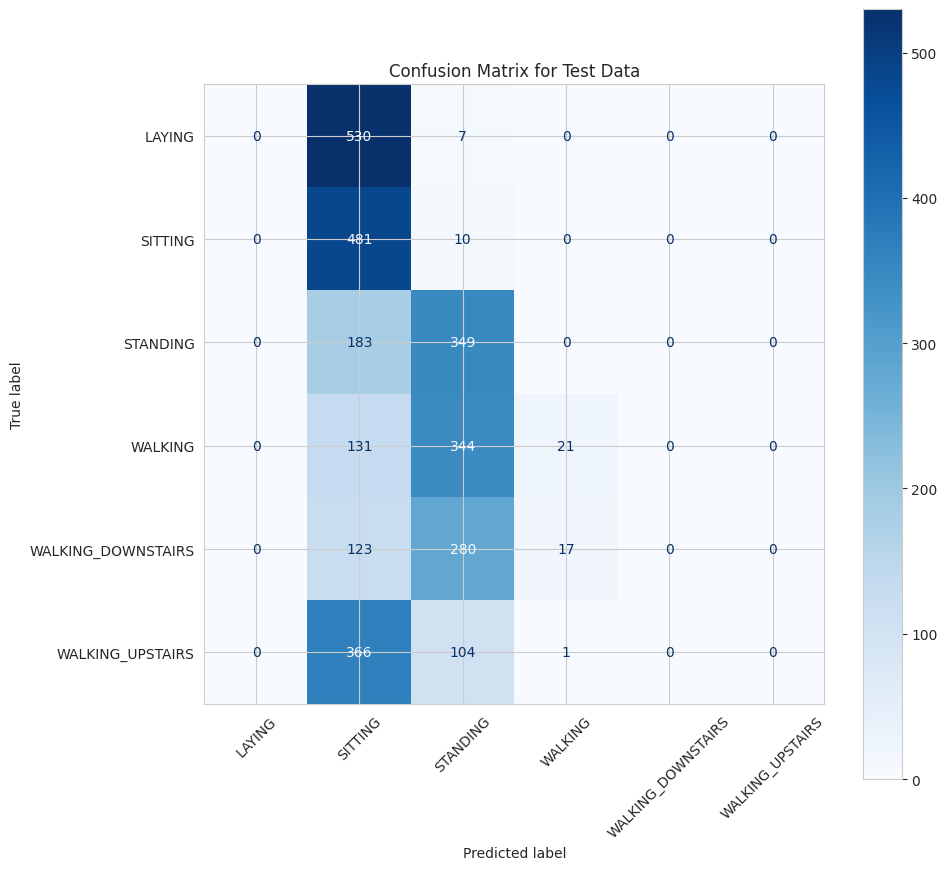

In [ ]:
# ------------------------------------------------------------------
# Evaluate CNN performance on the held-out test set
# ------------------------------------------------------------------

# Per-class classification report
print(classification_report(y_test_true, y_test_pred, target_names=le.classes_))

# Summary metrics
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_f1       = f1_score(y_test_true, y_test_pred, average='weighted')
print(f'CNN Test Accuracy : {test_accuracy:.4f}')
print(f'CNN Test F1 Score : {test_f1:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title('SimpleCNN — Confusion Matrix (Held-Out Test Set)')
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', size=0)
plt.tight_layout()
plt.show()


## 9. PCA with 30 Components — Component Analysis & SVM

In [ ]:
# ------------------------------------------------------------------
# Step 1: Fit PCA with 30 components on the same standardised,
# SMOTE-balanced training features used in Section 4.
# scaled_features and scaler are already available from above.
# ------------------------------------------------------------------
N_COMPONENTS_30 = 30
pca_30 = PCA(n_components=N_COMPONENTS_30)
pca_result_30 = pca_30.fit_transform(scaled_features)

total_var_30 = pca_30.explained_variance_ratio_.sum()
print(f"Transformed training set shape : {pca_result_30.shape}")
print(f"Variance explained by 30 PCs  : {total_var_30*100:.2f}%")
print(f"Variance explained by 100 PCs : {pca_95.explained_variance_ratio_.sum()*100:.2f}%  (reference)")

# Step 2: Per-component and cumulative explained variance plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, N_COMPONENTS_30 + 1),
            pca_30.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_title("Explained Variance per Component (30 PCs)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_xticks(range(1, N_COMPONENTS_30 + 1, 2))

cumvar_30 = np.cumsum(pca_30.explained_variance_ratio_) * 100
axes[1].plot(range(1, N_COMPONENTS_30 + 1), cumvar_30, marker="o", markersize=5)
axes[1].axhline(y=total_var_30 * 100, color="r", linestyle="--",
                label=f"Total: {total_var_30*100:.1f}%")
axes[1].set_title("Cumulative Explained Variance (30 PCs)")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Step 1: Inspect which original sensor features drive each PC.
# pca_30.components_ has shape (30, 561):
#   rows = principal components, columns = original features.
# ------------------------------------------------------------------
feature_names = list(X_raw.columns)
components    = pca_30.components_

# Step 2: Print the top 8 loading features for the first 5 PCs
print("Top 8 features (highest absolute loading) for PC1 to PC5:")
print()
for pc_idx in range(5):
    top_idx = np.argsort(np.abs(components[pc_idx]))[::-1][:8]
    print(f"PC{pc_idx + 1}:")
    for i in top_idx:
        print(f"  {feature_names[i]:<42s}  loading = {components[pc_idx][i]:+.4f}")
    print()

# Step 3: Heatmap — first 10 PCs vs the 25 features with the
# highest total absolute loading across those PCs.
N_PCS_SHOWN  = 10
N_FEAT_SHOWN = 25

overall_abs = np.sum(np.abs(components[:N_PCS_SHOWN, :]), axis=0)
top_feat_idx   = np.argsort(overall_abs)[::-1][:N_FEAT_SHOWN]
top_feat_names = [feature_names[i] for i in top_feat_idx]

loadings_subset = components[:N_PCS_SHOWN, top_feat_idx]

plt.figure(figsize=(15, 5))
sns.heatmap(loadings_subset,
            xticklabels=top_feat_names,
            yticklabels=[f"PC{i+1}" for i in range(N_PCS_SHOWN)],
            cmap="coolwarm", center=0, linewidths=0.3)
plt.title(f"PCA Loadings: First {N_PCS_SHOWN} PCs vs Top {N_FEAT_SHOWN} Most Influential Features")
plt.xlabel("Original Sensor Feature")
plt.ylabel("Principal Component")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Step 1: Build a 30-component PCA DataFrame from the balanced
# training data and attach integer-encoded activity labels.
# ------------------------------------------------------------------
pca_columns_30 = [f"PC{i+1}" for i in range(N_COMPONENTS_30)]
pca_df_30 = pd.DataFrame(data=pca_result_30, columns=pca_columns_30)
pca_df_30["Activity"] = le.transform(train_data_balanced["Activity"].values)

X_pca30 = pca_df_30.drop(["Activity"], axis=1).values
y_pca30 = pca_df_30["Activity"].values

# Step 2: Stratified 80/20 split (same seed as the 100-PC SVM)
X_train_30, X_val_30, y_train_30, y_val_30 = train_test_split(
    X_pca30, y_pca30, test_size=0.2, random_state=42, stratify=y_pca30)

# Step 3: Train SVM on 30-component PCA features
svm_pca30 = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
svm_pca30.fit(X_train_30, y_train_30)

# Validation set
y_pred_val_30 = svm_pca30.predict(X_val_30)
print("=== Validation Set: SVM with 30 PCA Components ===")
print(classification_report(y_val_30, y_pred_val_30, target_names=le.classes_))
val_acc_pca30 = accuracy_score(y_val_30, y_pred_val_30)
val_f1_pca30  = f1_score(y_val_30, y_pred_val_30, average="weighted")

# Step 4: Transform the held-out test set with the same scaler and pca_30
X_test_scaled_30 = scaler.transform(X_test_raw)
X_test_pca_30    = pca_30.transform(X_test_scaled_30)

y_pred_test_30 = svm_pca30.predict(X_test_pca_30)
print("=== Held-Out Test Set: SVM with 30 PCA Components ===")
print(classification_report(y_test_encoded, y_pred_test_30, target_names=le.classes_))
test_acc_pca30 = accuracy_score(y_test_encoded, y_pred_test_30)
test_f1_pca30  = f1_score(y_test_encoded, y_pred_test_30, average="weighted")

# Confusion matrix on the test set
cm = confusion_matrix(y_test_encoded, y_pred_test_30)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SVM (30 PCA Components) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()

print(f"SVM (PCA-30)  | Val  Acc: {val_acc_pca30:.4f}  F1: {val_f1_pca30:.4f}")
print(f"SVM (PCA-30)  | Test Acc: {test_acc_pca30:.4f}  F1: {test_f1_pca30:.4f}")
print(f"SVM (PCA-100) | Val  Acc: {svm_accuracy:.4f}  F1: {svm_f1:.4f}  [Section 5 reference]")


## 10. Random Forest Feature Importance — Top 30 Features & SVM

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------------
# Step 1: Train a Random Forest on the SMOTE-balanced training data.
# X_balanced (N x 561) and y_balanced are from Section 3.
# RF is scale-invariant, so the pre-scaled balanced features are fine.
# ------------------------------------------------------------------
print("Training Random Forest on all 561 original features ...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_balanced, y_balanced)
print("Training complete.")

# Step 2: Rank features by mean decrease in impurity (Gini importance)
feature_names_rf  = list(X_raw.columns)
importances       = rf.feature_importances_
sorted_idx        = np.argsort(importances)[::-1]

TOP_N             = 30
top30_idx         = sorted_idx[:TOP_N]
top30_names       = [feature_names_rf[i] for i in top30_idx]
top30_importances = importances[top30_idx]

print('\nTop ' + str(TOP_N) + ' features by Random Forest importance:')
print('{:<5} {:<45} {:>12}'.format('Rank', 'Feature', 'Importance'))
print('-' * 64)
for rank, (name, imp) in enumerate(zip(top30_names, top30_importances), 1):
    print('{:<5} {:<45} {:>12.6f}'.format(rank, name, imp))

# Step 3: Horizontal bar chart (most important at the top)
plt.figure(figsize=(12, 9))
plt.barh(range(TOP_N - 1, -1, -1), top30_importances, color='steelblue')
plt.yticks(range(TOP_N - 1, -1, -1), top30_names)
plt.xlabel('Feature Importance (mean decrease in impurity)')
plt.title('Top ' + str(TOP_N) + ' Sensor Features by Random Forest Importance')
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Step 1: Extract the top 30 RF-selected columns from training data.
# X_balanced is already standardised; SVM is not scale-invariant,
# but the features are already in a comparable range from the
# StandardScaler applied in Section 3.
# ------------------------------------------------------------------
X_rf_top30  = X_balanced[:, top30_idx]
y_rf_labels = y_balanced

# Step 2: Stratified 80/20 split
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_rf_top30, y_rf_labels,
    test_size=0.2, random_state=42, stratify=y_rf_labels)
print(f"Train: {X_train_rf.shape}  |  Val: {X_val_rf.shape}")

# Step 3: Train SVM on the 30 most informative original features
svm_rf30 = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
svm_rf30.fit(X_train_rf, y_train_rf)

# Validation set
y_pred_val_rf = svm_rf30.predict(X_val_rf)
print("=== Validation Set: SVM with Top 30 RF Features ===")
print(classification_report(y_val_rf, y_pred_val_rf, target_names=le.classes_))
val_acc_rf30 = accuracy_score(y_val_rf, y_pred_val_rf)
val_f1_rf30  = f1_score(y_val_rf, y_pred_val_rf, average="weighted")

# Step 4: Apply the same standardisation to the raw test features,
# then select the identical 30-column subset found by the RF.
X_test_scaled_rf = scaler.transform(X_test_raw)
X_test_rf30      = X_test_scaled_rf[:, top30_idx]

y_pred_test_rf = svm_rf30.predict(X_test_rf30)
print("=== Held-Out Test Set: SVM with Top 30 RF Features ===")
print(classification_report(y_test_encoded, y_pred_test_rf, target_names=le.classes_))
test_acc_rf30 = accuracy_score(y_test_encoded, y_pred_test_rf)
test_f1_rf30  = f1_score(y_test_encoded, y_pred_test_rf, average="weighted")

# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_test_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SVM (Top 30 RF Features) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()

print(f"SVM (RF-30 features) | Val  Acc: {val_acc_rf30:.4f}  F1: {val_f1_rf30:.4f}")
print(f"SVM (RF-30 features) | Test Acc: {test_acc_rf30:.4f}  F1: {test_f1_rf30:.4f}")


## 11. Summary — SVM Feature-Set Comparison

In [ ]:
# ------------------------------------------------------------------
# Side-by-side comparison of all three SVM configurations
# on the held-out test set.
# ------------------------------------------------------------------
header = f"{chr(34)}Model{chr(34):<47} {chr(34)}Test Acc{chr(34):>9} {chr(34)}Test F1{chr(34):>8}  Feature set"
rows = [
    ("SVM  100 PCA components  (Section 5)",  svm_accuracy,   svm_f1,        "100 PCs  from 561 sensor features"),
    ("SVM   30 PCA components  (Section 9)",  test_acc_pca30, test_f1_pca30, " 30 PCs  from 561 sensor features"),
    ("SVM   30 RF-selected features (Sec.10)",test_acc_rf30,  test_f1_rf30,  " 30 original features (RF-ranked)"),
]

print(f"{chr(45)*95}")
print(f"  {"Model":<45} {"Test Acc":>10} {"Test F1":>9}  Feature set")
print(f"{chr(45)*95}")
for name, acc, f1, feat_desc in rows:
    print(f"  {name:<45} {acc:>10.4f} {f1:>9.4f}  {feat_desc}")
print(f"{chr(45)*95}")


## 12. Full Test-Set Evaluation — All Models Compared

In [ ]:
# ------------------------------------------------------------------
# SVM with 100 PCA components — held-out test set
# The Section 5 SVM was only evaluated on a validation split.
# Here we run it against the actual test set for the first time.
# scaler and pca_95 were fitted on training data (no leakage).
# ------------------------------------------------------------------
X_test_scaled_100 = scaler.transform(X_test_raw)
X_test_pca_100    = pca_95.transform(X_test_scaled_100)

y_pred_test_svm100 = svm_model.predict(X_test_pca_100)
print("=== SVM (100 PCA components) — Held-Out Test Set ===")
print(classification_report(y_test_encoded, y_pred_test_svm100, target_names=le.classes_))
test_acc_svm100 = accuracy_score(y_test_encoded, y_pred_test_svm100)
test_f1_svm100  = f1_score(y_test_encoded, y_pred_test_svm100, average="weighted")

cm = confusion_matrix(y_test_encoded, y_pred_test_svm100)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SVM (100 PCA Components) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()
print(f"SVM (PCA-100) | Test Acc: {test_acc_svm100:.4f}  Test F1: {test_f1_svm100:.4f}")


In [ ]:
# ------------------------------------------------------------------
# SimpleNN — held-out test set
# The best NN model was saved during cross-validation (Section 6).
# Test features are the same 100-component PCA space.
# ------------------------------------------------------------------
X_test_nn_tensor = (torch.tensor(X_test_pca_100, dtype=torch.float32)
                    .to(device))

best_nn_test = SimpleNN(input_size=X_test_pca_100.shape[1],
                        num_classes=len(le.classes_)).to(device)
best_nn_test.load_state_dict(torch.load("best_model_NN.pth", map_location=device))
best_nn_test.eval()

with torch.no_grad():
    nn_test_out  = best_nn_test(X_test_nn_tensor)
    nn_test_pred = torch.argmax(nn_test_out, dim=1).cpu().numpy()

print("=== SimpleNN (100 PCA components) — Held-Out Test Set ===")
print(classification_report(y_test_encoded, nn_test_pred, target_names=le.classes_))
test_acc_nn = accuracy_score(y_test_encoded, nn_test_pred)
test_f1_nn  = f1_score(y_test_encoded, nn_test_pred, average="weighted")

cm = confusion_matrix(y_test_encoded, nn_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SimpleNN (100 PCA Components) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()
print(f"SimpleNN (PCA-100) | Test Acc: {test_acc_nn:.4f}  Test F1: {test_f1_nn:.4f}")


In [ ]:
# ------------------------------------------------------------------
# Comprehensive comparison of every model on the held-out test set.
# Val Acc uses the best cross-validation fold where applicable.
# ------------------------------------------------------------------

rows = [
    # (model_name, feature_set, val_acc, test_acc, test_f1)
    ("SVM",      "PCA-100 (100 components)",  svm_accuracy,          test_acc_svm100, test_f1_svm100),
    ("SimpleNN", "PCA-100 (100 components)",  best_val_accuracy_nn,  test_acc_nn,     test_f1_nn),
    ("CNN",      "PCA-100 (100 components)",  best_val_accuracy_cnn, test_accuracy,   test_f1),
    ("SVM",      "PCA-30  ( 30 components)",  val_acc_pca30,         test_acc_pca30,  test_f1_pca30),
    ("SVM",      "Top-30 RF features",          val_acc_rf30,          test_acc_rf30,   test_f1_rf30),
]

sep = '-' * 88
header = '  {:<10} {:<28} {:>9} {:>10} {:>9}'.format(
    'Model', 'Feature set', 'Val Acc', 'Test Acc', 'Test F1'
)

print(sep)
print(header)
print(sep)
for model, feats, val_a, test_a, test_f in rows:
    line = '  {:<10} {:<28} {:>9.4f} {:>10.4f} {:>9.4f}'.format(
        model, feats, val_a, test_a, test_f)
    print(line)
print(sep)

best = max(rows, key=lambda r: r[3])
print('\nBest test accuracy: ' + best[0] + ' (' + best[1] + ')  ->  ' + f'{best[3]:.4f}')
